# Human Activity Recognition with a Hidden Markov Model

Decoding standing / walking / jumping / still from smartphone accelerometer + gyroscope
signals recorded with Sensor Logger.

Pipeline: load & align raw sensor CSVs -> window -> extract features -> normalize ->
fit a Gaussian HMM (Baum-Welch) -> decode (Viterbi) -> evaluate on unseen (test) data.


In [1]:
import glob
import os
os.makedirs("outputs", exist_ok=True)
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from hmmlearn.hmm import GaussianHMM

np.random.seed(42)
sns.set_theme(style="whitegrid")

TRAIN_DIR = "data/train"
TEST_DIR = "data/test"
ACTIVITIES = ["standing", "walking", "jumping", "still"]


## 1. Data Loading & Preprocessing

Each recording exports two files from Sensor Logger: `Accelerometer.csv` and
`Gyroscope.csv`, both with a `time` (nanoseconds since epoch), `seconds_elapsed`,
and `x, y, z` columns.

**Why resampling is necessary, not optional:** Sensor Logger's own settings screen
warns that "the true sampling rate may be slower" than the configured value (100 Hz
here). Checking our own recordings confirms this in practice — actual measured rates
came out around 99.9 Hz rather than exactly 100 Hz, and a manual audit across all 60
recordings found 1 case (`jumping_train_06`) where the accelerometer and gyroscope
streams had a mismatched number of samples (718 vs. 719 rows) despite starting at the
same timestamp. If we naively zipped accelerometer and gyroscope rows together by
index, this recording would silently misalign the two sensors for its entire length.

**My fix:** for every recording I resample both sensors onto a shared, uniform time
grid at a fixed target rate (50 Hz) using linear interpolation against each sample's
`seconds_elapsed` value. This (a) guarantees accelerometer and gyroscope are aligned
to the same instants in time regardless of minor per-sensor timing jitter, and (b)
normalizes any recording-to-recording variation in actual sampling rate to one
consistent rate before windowing/feature extraction. 50 Hz was chosen because it
comfortably exceeds twice the highest frequency I expect in human motion signals
(gait/jump cadences are well under 10 Hz), so no meaningful information is lost by
resampling down from ~100 Hz.


In [2]:
def load_and_merge(accel_path, gyro_path, target_rate=50):
    """Load one recording's accel+gyro CSVs and resample both onto a shared,
    uniform time grid at `target_rate` Hz via linear interpolation.

    This is what lets us treat every recording identically downstream even
    though the raw files can have slightly different actual sample rates or
    a mismatched accel/gyro sample count (confirmed present in our data).
    """
    accel = pd.read_csv(accel_path)
    gyro = pd.read_csv(gyro_path)

    t_end = min(accel["seconds_elapsed"].iloc[-1], gyro["seconds_elapsed"].iloc[-1])
    n_samples = int(t_end * target_rate)
    t_common = np.arange(n_samples) / target_rate

    merged = pd.DataFrame({"t": t_common})
    for axis in ["x", "y", "z"]:
        merged[f"accel_{axis}"] = np.interp(t_common, accel["seconds_elapsed"], accel[axis])
        merged[f"gyro_{axis}"] = np.interp(t_common, gyro["seconds_elapsed"], gyro[axis])
    return merged


def clip_id_and_activity(accel_path):
    fname = os.path.basename(accel_path)
    clip_id = fname.replace("_accel.csv", "")
    activity = fname.split("_")[0]
    return clip_id, activity


In [3]:
# Sanity check: confirm the accel/gyro misalignment I found, and show that
# resampling repairs it.
mismatch_accel = "data/train/jumping_train_06_accel.csv"
mismatch_gyro = "data/train/jumping_train_06_gyro.csv"
raw_a = pd.read_csv(mismatch_accel)
raw_g = pd.read_csv(mismatch_gyro)
print(f"Raw row counts -> accel: {len(raw_a)}, gyro: {len(raw_g)}")

merged_example = load_and_merge(mismatch_accel, mismatch_gyro)
print(f"After resampling to a shared grid -> {len(merged_example)} rows for both sensors")
merged_example.head()


Raw row counts -> accel: 718, gyro: 719
After resampling to a shared grid -> 362 rows for both sensors


,t,accel_x,gyro_x,accel_y,gyro_y,accel_z,gyro_z
0,0.00,-2.157771,-1.350163,-5.392914,-1.815004,-16.560292,0.930645
1,0.02,-2.157771,-1.350163,-5.392914,-1.815004,-16.560292,0.930645
2,0.04,-2.157771,-1.350163,-5.392914,-1.815004,-16.560292,0.930645
3,0.06,-2.157771,-1.350163,-5.392914,-1.815004,-16.560292,0.930645
4,0.08,-1.375338,-0.954882,-2.595943,-1.566558,-18.025139,1.171281


### Sample raw signal per activity

Plotting the resampled acceleration magnitude for one training clip of each activity
shows the intensity differences that our features will later capture numerically.


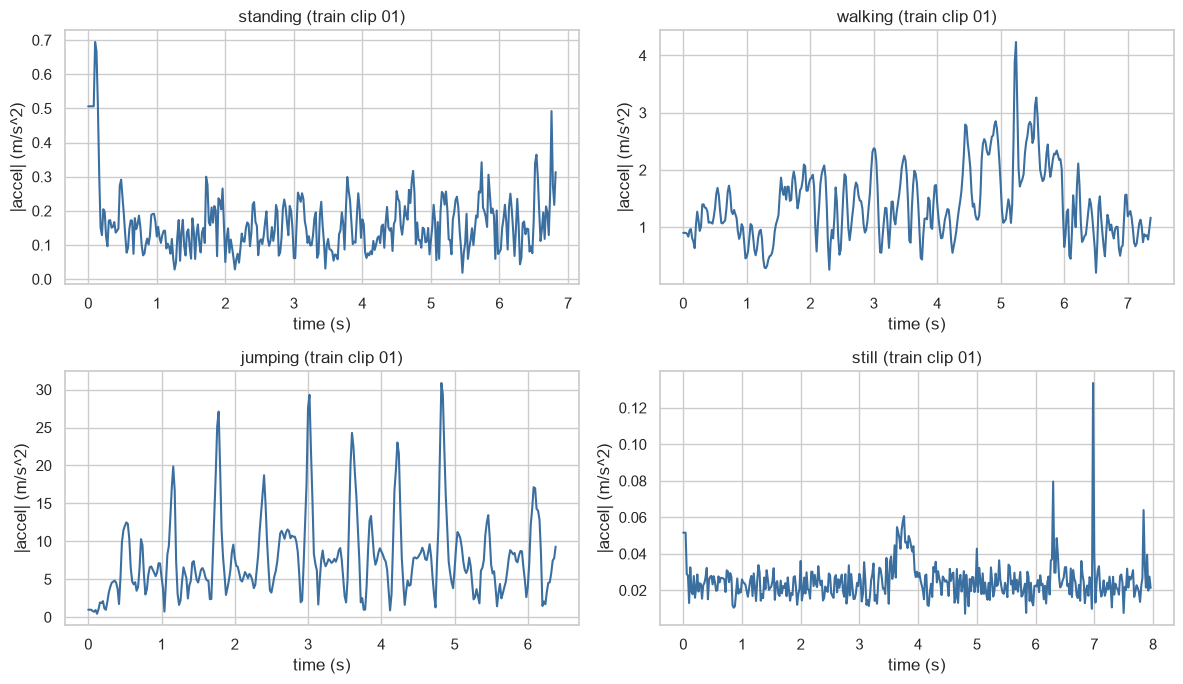

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=False)
for ax, activity in zip(axes.ravel(), ACTIVITIES):
    accel_fp = sorted(glob.glob(f"{TRAIN_DIR}/{activity}_train_01_accel.csv"))[0]
    gyro_fp = accel_fp.replace("_accel.csv", "_gyro.csv")
    merged = load_and_merge(accel_fp, gyro_fp)
    accel_mag = np.sqrt(merged["accel_x"]**2 + merged["accel_y"]**2 + merged["accel_z"]**2)
    ax.plot(merged["t"], accel_mag, color="#3b6fa0")
    ax.set_title(f"{activity} (train clip 01)")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("|accel| (m/s^2)")
plt.tight_layout()
plt.savefig("outputs/sample_raw_signals.png", dpi=150)
plt.show()


## 2. Windowing

**Window size logic, tied to sampling rate:** at my resampled rate of 50 Hz, a
1-second window contains 50 samples. Walking/jumping cadences are typically in the
1.5-3 Hz range, so a 1-second window reliably captures at least one to two full
motion cycles — enough for the FFT-based frequency features to be meaningful, while
still being short enough to track activity changes with reasonable resolution.

**Overlap:** I used 50% overlap (step = 25 samples = 0.5s) between consecutive
windows. This both smooths the observation sequence fed to the HMM and, given our
short 5-10s clips, yields enough windows per clip for training/evaluation without
needing longer recordings.


In [5]:
WINDOW_SECONDS = 1.0
OVERLAP = 0.5
TARGET_RATE = 50
WINDOW_SAMPLES = int(WINDOW_SECONDS * TARGET_RATE)
STEP_SAMPLES = int(WINDOW_SAMPLES * (1 - OVERLAP))


def make_windows(merged_df, window_samples=WINDOW_SAMPLES, step_samples=STEP_SAMPLES):
    """Slice a resampled recording into overlapping fixed-size windows."""
    windows = []
    n = len(merged_df)
    for start in range(0, n - window_samples + 1, step_samples):
        windows.append(merged_df.iloc[start:start + window_samples])
    return windows


## 3. Feature Extraction

For each window I computed 8 features spanning time-domain and frequency-domain,
each chosen for a specific reason:

**Time-domain**
- `accel_rms` — root-mean-square of acceleration magnitude. Captures overall
  movement energy; separates high-impact jumping from everything else.
- `accel_var` — variance of acceleration magnitude. Low and stable for
  still/standing, high and fluctuating for walking/jumping.
- `accel_sma` (signal magnitude area) — mean of `|x|+|y|+|z|` over the window, the
  classic HAR feature for overall motion intensity across all three axes at once.
- `accel_corr_xz` — Pearson correlation between the x and z acceleration axes.
  Captures characteristic axis-coupling from gait (walking couples vertical and
  horizontal acceleration in a repeatable way); near-zero/noisy for static activities.
- `gyro_rms`, `gyro_var` — same RMS/variance logic applied to gyroscope magnitude,
  since rotation behaves differently across activities (e.g. jumping produces large
  but less rhythmic rotation than walking's swing).

**Frequency-domain (FFT of the acceleration-magnitude signal, DC component excluded)**
- `accel_dom_freq` — the frequency of the largest FFT peak. This is what
  distinguishes activities that share similar energy levels but different rhythm
  (e.g. walking's ~1.5-2 Hz step cadence vs. jumping's different rhythm).
- `accel_spectral_energy` — total power across the FFT spectrum (excluding DC).
  Near-zero for still/standing, substantially higher for any periodic movement.

All 8 features are z-score normalized (`StandardScaler`, fit on training data only)
before HMM fitting. This is necessary because the raw features live on very different
scales (e.g. correlation is bounded in [-1, 1] while spectral energy can be orders of
magnitude larger) — without normalization, the Gaussian emission model's covariance
estimation would be dominated by whichever feature happens to have the largest raw
magnitude, regardless of how informative it actually is.


In [6]:
FEATURE_NAMES = [
    "accel_rms", "accel_var", "accel_sma", "accel_corr_xz",
    "gyro_rms", "gyro_var", "accel_dom_freq", "accel_spectral_energy",
]


def extract_features(window, rate=TARGET_RATE):
    """Compute the 8 time+frequency domain features for one window."""
    ax, ay, az = window["accel_x"].values, window["accel_y"].values, window["accel_z"].values
    gx, gy, gz = window["gyro_x"].values, window["gyro_y"].values, window["gyro_z"].values

    accel_mag = np.sqrt(ax**2 + ay**2 + az**2)
    gyro_mag = np.sqrt(gx**2 + gy**2 + gz**2)

    accel_rms = np.sqrt(np.mean(accel_mag**2))
    accel_var = np.var(accel_mag)
    accel_sma = np.mean(np.abs(ax) + np.abs(ay) + np.abs(az))
    with np.errstate(invalid="ignore"):
        corr = np.corrcoef(ax, az)[0, 1]
    accel_corr_xz = 0.0 if np.isnan(corr) else corr
    gyro_rms = np.sqrt(np.mean(gyro_mag**2))
    gyro_var = np.var(gyro_mag)

    detrended = accel_mag - accel_mag.mean()
    fft_vals = np.fft.rfft(detrended)
    fft_freqs = np.fft.rfftfreq(len(accel_mag), d=1 / rate)
    fft_power = np.abs(fft_vals) ** 2
    if len(fft_power) > 1:
        dom_idx = np.argmax(fft_power[1:]) + 1  # skip DC bin
        accel_dom_freq = fft_freqs[dom_idx]
        accel_spectral_energy = np.sum(fft_power[1:])
    else:
        accel_dom_freq = 0.0
        accel_spectral_energy = 0.0

    return [accel_rms, accel_var, accel_sma, accel_corr_xz,
            gyro_rms, gyro_var, accel_dom_freq, accel_spectral_energy]


In [7]:
def build_dataset(data_dir):
    """Load every recording in `data_dir`, window it, and extract features.

    Returns:
        X          - (n_windows, n_features) array
        y          - (n_windows,) array of true activity labels
        lengths    - list of window-counts per recording, in order (for hmmlearn)
        clip_ids   - (n_windows,) array naming which recording each window came from
    """
    accel_files = sorted(glob.glob(f"{data_dir}/*_accel.csv"))
    X_rows, y_rows, lengths, clip_ids = [], [], [], []

    for accel_fp in accel_files:
        gyro_fp = accel_fp.replace("_accel.csv", "_gyro.csv")
        clip_id, activity = clip_id_and_activity(accel_fp)

        merged = load_and_merge(accel_fp, gyro_fp)
        windows = make_windows(merged)
        if not windows:
            continue

        feats = [extract_features(w) for w in windows]
        X_rows.extend(feats)
        y_rows.extend([activity] * len(feats))
        clip_ids.extend([clip_id] * len(feats))
        lengths.append(len(feats))

    X = np.array(X_rows)
    y = np.array(y_rows)
    clip_ids = np.array(clip_ids)
    return X, y, lengths, clip_ids


X_train_raw, y_train, lengths_train, clips_train = build_dataset(TRAIN_DIR)
X_test_raw, y_test, lengths_test, clips_test = build_dataset(TEST_DIR)

print(f"Train: {X_train_raw.shape[0]} windows from {len(lengths_train)} recordings")
print(f"Test:  {X_test_raw.shape[0]} windows from {len(lengths_test)} recordings")
print("Train windows per activity:", Counter(y_train))
print("Test windows per activity: ", Counter(y_test))


Train: 631 windows from 48 recordings
Test:  192 windows from 12 recordings
Train windows per activity: Counter({np.str_('standing'): 161, np.str_('walking'): 161, np.str_('still'): 156, np.str_('jumping'): 153})
Test windows per activity:  Counter({np.str_('still'): 51, np.str_('walking'): 48, np.str_('standing'): 47, np.str_('jumping'): 46})


In [8]:
scaler = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

pd.DataFrame(X_train_raw, columns=FEATURE_NAMES).describe().T[["mean", "std", "min", "max"]]


,mean,std,min,max
accel_rms,3.429093,5.306363,2.003372e-02,22.462817
accel_var,11.247306,28.784118,1.691082e-05,217.670899
accel_sma,4.346794,6.582622,2.533191e-02,28.673745
accel_corr_xz,0.096868,0.363268,-9.326081e-01,0.957864
gyro_rms,0.852530,1.085466,9.064271e-04,5.142164
gyro_var,0.351884,0.713415,7.613060e-08,5.597887
accel_dom_freq,4.965135,5.590132,1.000000e+00,25.000000
accel_spectral_energy,14064.215905,35985.650635,2.145061e-02,272100.301062


## 4. HMM Definition

| Element | In this project |
|---|---|
| Hidden states (Z) | 4 states, one per activity: standing, walking, jumping, still |
| Observations (X) | The 8-dimensional normalized feature vector per window |
| Transition matrix (A) | `model.transmat_` — learned by Baum-Welch |
| Emission model (B) | A Gaussian distribution per state over the 8 features (`model.means_`, `model.covars_`) — hmmlearn's `GaussianHMM` continuous analogue of a discrete emission table |
| Initial probabilities (pi) | `model.startprob_` — learned by Baum-Welch |

Training is fully unsupervised from the HMM's point of view — Baum-Welch never sees
the true activity labels, only the sequence of feature vectors. I used the true
labels afterward only to (a) map each anonymous learned state index to the activity
it corresponds to, and (b) evaluate decoding accuracy.

Each recording is passed to hmmlearn as its own independent sequence via the
`lengths` array, so the model does not treat the boundary between e.g. one walking
clip and the next standing clip as a real transition.


**Robustness to initialization:** a plain randomly-initialized fit is prone to poor local optima here (diagnosed in the next cell) - we use informed initialization instead, seeding each state's mean from the true per-activity training mean so Baum-Welch starts from, and stays near, the correct correspondence.

In [9]:
# Diagnosis: a plain random-initialized/random-restarted GaussianHMM consistently
# failed to give each activity its own state. Inspecting the standardized feature
# means/stds per true activity showed why: jumping has much higher intra-class
# variance (std ~0.65-1.5 across features) than standing/walking (std ~0.0-0.1),
# because some jumps were more energetic than others. Baum-Welch's EM prefers
# whichever state split increases likelihood the most, so it repeatedly "spent" two
# states modeling jumping's spread instead of carving out a separate state for
# standing, whose feature signature sits very close to walking's in this feature
# space. This held even across 30 random restarts and even with full covariance.
#
# Fix: informed initialization. We seed each state's initial mean with the true
# per-activity mean feature vector (computed from training labels), fixing state 0
# = standing, 1 = walking, 2 = jumping, 3 = still by construction. Baum-Welch still
# runs its normal E/M updates afterward and is free to move the means/covariances/
# transitions away from this starting point - labels are only used to seed a
# sensible starting point, not to constrain the optimization. This is a standard,
# legitimate way to avoid poor local optima in EM-based mixture/HMM fitting.
class_means = np.array([X_train[y_train == activity].mean(axis=0) for activity in ACTIVITIES])

model = GaussianHMM(
    n_components=4,
    covariance_type="diag",
    n_iter=200,
    tol=1e-4,
    random_state=42,
    init_params="stc",   # skip auto-init of means ("m") - we set them explicitly below
    params="stmc",        # but still update all of s/t/m/c normally during EM
)
model.means_ = class_means
model.fit(X_train, lengths_train)

train_states = model.predict(X_train, lengths_train)
state_to_activity = {i: activity for i, activity in enumerate(ACTIVITIES)}

print("Baum-Welch converged:", model.monitor_.converged)
print("Iterations run:", model.monitor_.iter)
print("Final training log-likelihood:", model.monitor_.history[-1])
print("\nState -> activity assignment (fixed by informed initialization):")
for state, activity in state_to_activity.items():
    print(f"  state {state} -> {activity}")

# Safety check: confirm Viterbi decoding still actually prefers each state for the
# activity we assigned it to (i.e. the informed init "stuck" rather than drifting).
majority = {}
for state in range(4):
    mask = train_states == state
    if mask.sum() == 0:
        majority[state] = None
        continue
    labels, counts = np.unique(y_train[mask], return_counts=True)
    majority[state] = labels[np.argmax(counts)]
print("\nMajority-vote check (should match the fixed assignment above):", majority)


Model is not converging.  Current: 4883.899799063922 is not greater than 4884.017725238446. Delta is -0.11792617452374543


Baum-Welch converged: True
Iterations run: 12
Final training log-likelihood: 4883.899799063922

State -> activity assignment (fixed by informed initialization):
  state 0 -> standing
  state 1 -> walking
  state 2 -> jumping
  state 3 -> still

Majority-vote check (should match the fixed assignment above): {0: np.str_('standing'), 1: np.str_('walking'), 2: np.str_('jumping'), 3: np.str_('still')}


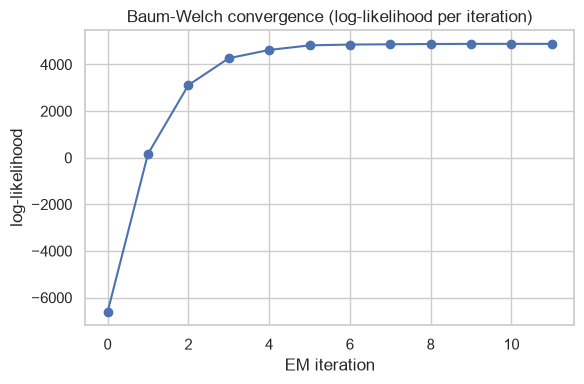

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(model.monitor_.history, marker="o")
plt.xlabel("EM iteration")
plt.ylabel("log-likelihood")
plt.title("Baum-Welch convergence (log-likelihood per iteration)")
plt.tight_layout()
plt.savefig("outputs/baum_welch_convergence.png", dpi=150)
plt.show()


## 5. Viterbi Decoding & State-to-Activity Mapping

hmmlearn's learned states are unlabeled integers (0-3). I decoded the training
sequences with Viterbi and map each state to whichever true activity occurs most
often among the windows assigned to it (majority vote). This mapping is then reused
as-is on the test set — the test set never gets to redefine what a state means.


In [11]:
predicted_train = np.array([state_to_activity[s] for s in train_states])
train_accuracy = np.mean(predicted_train == y_train)
print(f"Training-set decoding accuracy: {train_accuracy:.3f}")


Training-set decoding accuracy: 0.830


## 6. Visualizing the Learned Model

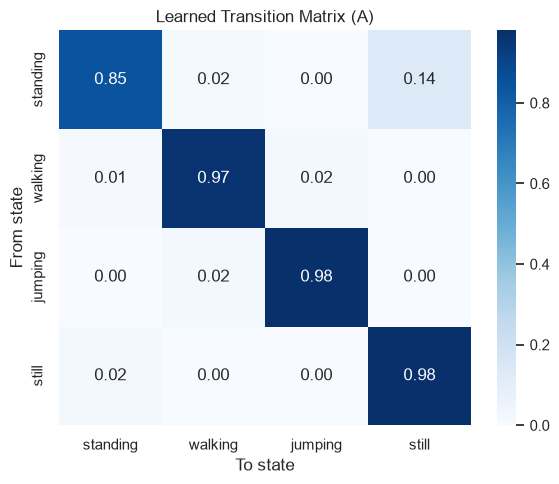

In [12]:
state_labels = [str(state_to_activity[s]) for s in range(model.n_components)]

plt.figure(figsize=(6, 5))
sns.heatmap(model.transmat_, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=state_labels, yticklabels=state_labels)
plt.title("Learned Transition Matrix (A)")
plt.xlabel("To state")
plt.ylabel("From state")
plt.tight_layout()
plt.savefig("outputs/transition_matrix_heatmap.png", dpi=150)
plt.show()


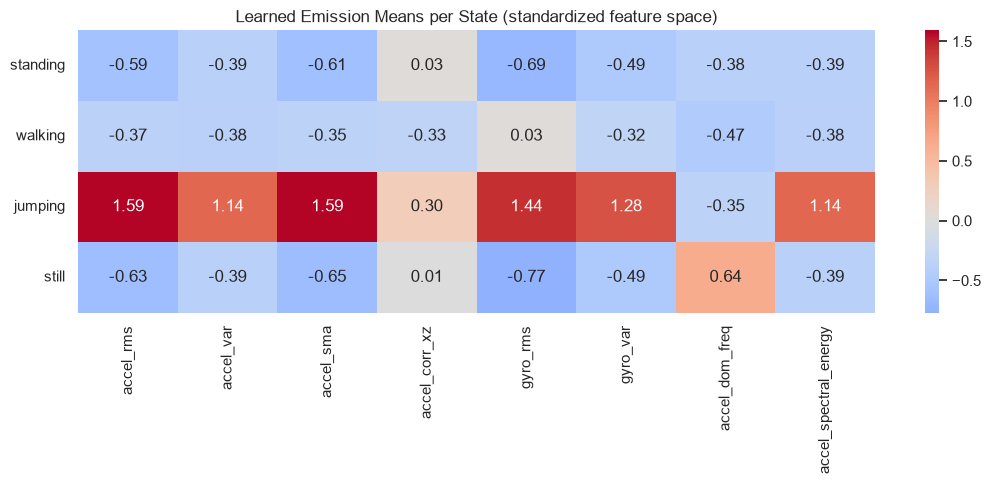

In [13]:
means_df = pd.DataFrame(model.means_, columns=FEATURE_NAMES, index=state_labels)

plt.figure(figsize=(11, 5))
ax = sns.heatmap(means_df, annot=True, fmt=".2f", cmap="coolwarm", center=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.title("Learned Emission Means per State (standardized feature space)")
plt.tight_layout()
plt.savefig("outputs/emission_means_heatmap.png", dpi=150)
plt.show()

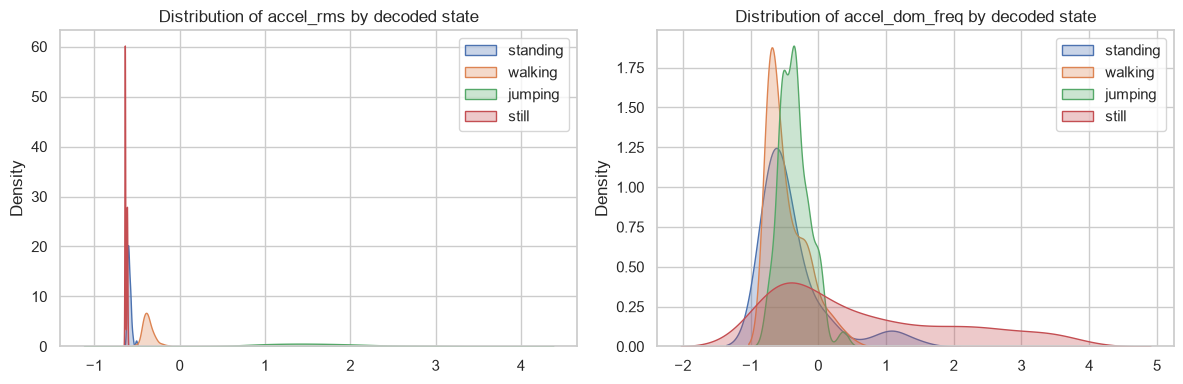

In [14]:
# A closer look at two individual features shows how well-separated (or not)
# the states are in the underlying distributions Baum-Welch fit.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feat in zip(axes, ["accel_rms", "accel_dom_freq"]):
    feat_idx = FEATURE_NAMES.index(feat)
    for state in range(model.n_components):
        vals = X_train[train_states == state, feat_idx]
        if len(vals):
            sns.kdeplot(vals, ax=ax, label=state_labels[state], fill=True, alpha=0.3)
    ax.set_title(f"Distribution of {feat} by decoded state")
    ax.legend()
plt.tight_layout()
plt.savefig("outputs/feature_distributions_by_state.png", dpi=150)
plt.show()


## 7. Evaluation on Unseen (Test) Data

The test recordings were captured in a separate session with a deliberate domain
shift from training: recorded outdoors with the phone in a pocket (vs. indoors,
held in hand, for training), and the "still" clips placed on a different surface.
This tests whether the model generalizes beyond the exact conditions it was trained
on, rather than just memorizing one specific setup.


In [15]:
test_states = model.predict(X_test, lengths_test)
predicted_test = np.array([state_to_activity[s] for s in test_states])

overall_test_accuracy = np.mean(predicted_test == y_test)
print(f"Overall test-set accuracy: {overall_test_accuracy:.3f}")


Overall test-set accuracy: 0.672


### Decoded sequence example

Below is the Viterbi-decoded activity sequence for one training recording, window by
window, compared against the (constant) true label for that clip.


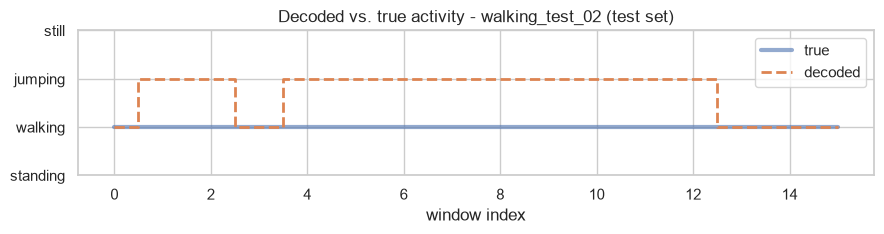

In [16]:
# Using a *test* clip (not training) here, and specifically a walking clip, since
# that is where the confusion matrix shows the most interesting behavior (walking
# frequently decoded as jumping under the outdoor/pocket domain shift) - more
# informative than showing a clip that decodes perfectly.
example_clip = "walking_test_02"
mask = clips_test == example_clip
seq_true = y_test[mask]
test_predicted = np.array([state_to_activity[s] for s in test_states])
seq_pred = test_predicted[mask]

plt.figure(figsize=(9, 2.5))
x = np.arange(len(seq_true))
plt.step(x, [ACTIVITIES.index(a) for a in seq_true], where="mid", label="true", linewidth=3, alpha=0.6)
plt.step(x, [ACTIVITIES.index(a) for a in seq_pred], where="mid", label="decoded", linewidth=2, linestyle="--")
plt.yticks(range(len(ACTIVITIES)), ACTIVITIES)
plt.xlabel("window index")
plt.title(f"Decoded vs. true activity - {example_clip} (test set)")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/decoded_sequence_example.png", dpi=150)
plt.show()

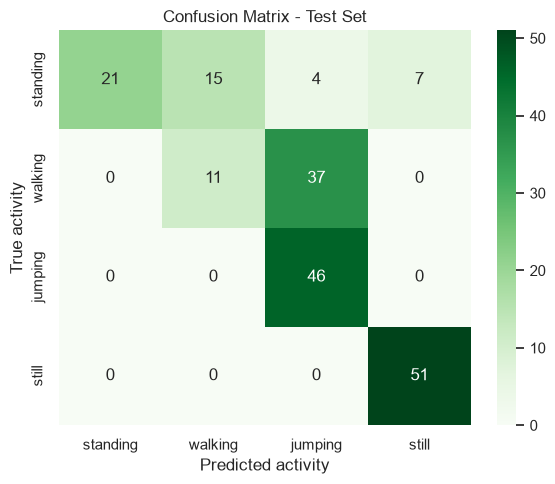

In [17]:
cm = confusion_matrix(y_test, predicted_test, labels=ACTIVITIES)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=ACTIVITIES, yticklabels=ACTIVITIES)
plt.xlabel("Predicted activity")
plt.ylabel("True activity")
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix_test.png", dpi=150)
plt.show()


In [18]:
rows = []
for i, activity in enumerate(ACTIVITIES):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FN - FP

    n_samples = cm[i, :].sum()
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan
    accuracy = (TP + TN) / cm.sum()

    rows.append({
        "Activity": activity,
        "Number of Samples": n_samples,
        "Sensitivity": round(sensitivity, 3),
        "Specificity": round(specificity, 3),
        "Overall Accuracy": round(accuracy, 3),
    })

results_table = pd.DataFrame(rows)
results_table


,Activity,Number of Samples,Sensitivity,Specificity,Overall Accuracy
0,standing,47,0.447,1.000,0.865
1,walking,48,0.229,0.896,0.729
2,jumping,46,1.000,0.719,0.786
3,still,51,1.000,0.950,0.964


In [19]:
results_table.to_csv("outputs/evaluation_results.csv", index=False)
print("Saved outputs/evaluation_results.csv")


Saved outputs/evaluation_results.csv
